**# AlexNet on CIFAR-10**



### ALL the importation

In [11]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torchvision
import torch.nn as nn

from torch.optim import SGD
from torchvision import transforms
from torchvision import datasets
from torch.utils.data import DataLoader, SubsetRandomSampler

# from mpmath.identification import transforms


In [21]:
print(torch.__version__)

print(torch.version.cuda)
print(torch.cuda.get_device_name(0))

torch.cuda.is_available()
torch.cuda.current_device()


2.11.0+cu128
12.8
NVIDIA GeForce RTX 2070 SUPER


0

# Settings and Dataset

In [13]:
# --- hyperparamètres ---
RANDOM_SEED = 123
BATCH_SIZE = 256
NUM_EPOCHES = 200
NUM_CLASSES = 3
LEARING_RATE = 0.0005
SCALE = 0.1
IMG_SIZE = (128, 128)
LATENT_DIM = 10

# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [14]:
train_transforms = transforms.Compose([
    transforms.Resize((70, 70)),
    transforms.RandomCrop((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
                                      ])

test_transforms = transforms.Compose([
    transforms.Resize((70, 70)),
    transforms.CenterCrop((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

#Load datasets
trainset = torchvision.datasets.CIFAR10(root='./data',
                                        train=True,
                                        download=True,
                                        transform=train_transforms)

testset = (torchvision.datasets.CIFAR10(root='./data',
                                        train=False,
                                        download=True,
                                        transform=test_transforms))

#create dataLoaders
trainloader = torch.utils.data.DataLoader(trainset,
                                          batch_size=4,
                                          shuffle=True,
                                          num_workers=0)

testloader = torch.utils.data.DataLoader(testset,
                                         batch_size=4,
                                         shuffle=False,
                                         num_workers=0)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

for images, labels in trainloader:
    print(f'Image batch dimensions: {images.shape}')
    print(f'Image label dimensions: {labels.shape}')
    print(f'Class labels of 10 examples: {labels[:10]}')
    break

Image batch dimensions: torch.Size([4, 3, 64, 64])
Image label dimensions: torch.Size([4])
Class labels of 10 examples: tensor([5, 7, 8, 5])


Images affichées:


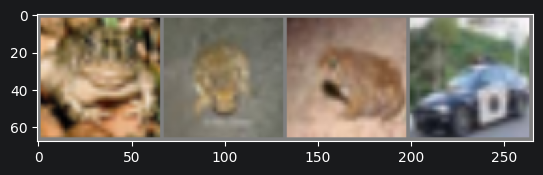

 frog  frog  frog   car


In [15]:
# Fonction pour afficher une image
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.cpu().numpy()  # Ajouté .cpu() pour gérer GPU
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
print("Images affichées:")
imshow(torchvision.utils.make_grid(images))
print(' '.join('%5s' % classes[labels[j]] for j in range(min(4, len(labels)))))


# Model Creation



In [16]:
# Device

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


# MODÈLE CORRIGÉ
class AlexNet(nn.Module):
    def __init__(self, num_classes):
        super(AlexNet, self).__init__()  # ← AJOUTÉ (IMPORTANT!)
        self.features = nn.Sequential(
            # Feature extraction bloc 1
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            # Bloc 2
            nn.Conv2d(64, 192, kernel_size=5, stride=1, padding=2),  # ← CORRIGÉ stride
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            # Bloc 3
            nn.Conv2d(192, 384, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            # Bloc 4
            nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            # Bloc 5
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Linear(6 * 6 * 256, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, num_classes),  # ← CORRIGÉ: output final
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), 256 * 6 * 6)
        logits = self.classifier(x)
        return logits

Device: cuda


In [6]:
#from torchinfo import summary
#torchinfo.summary(AlexNet)

# DATA Pre-Processing

# Constrution of AlexNet Layer

# Training Model

In [22]:

#import warnings
#from numpy import VisibleDeprecationWarning

#warnings.filterwarnings("ignore", category=VisibleDeprecationWarning)




# BOUCLE D'ENTRAÎNEMENT COMPLÈTE
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Entraîne le modèle pendant une époque."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Statistiques
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if (batch_idx + 1) % 100 == 0:
            print(f'Batch [{batch_idx + 1}/{len(train_loader)}], '
                  f'Loss: {loss.item():.4f}')

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc


def validate(model, test_loader, criterion, device):
    """Évalue le modèle sur l'ensemble de validation/test."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = running_loss / len(test_loader)
    val_acc = 100 * correct / total
    return val_loss, val_acc


def train_model(model, num_epochs, train_loader, test_loader,optimizer, criterion, devicescheduler=None):
    """Fonction principale d'entraînement."""
    train_losses = []
    train_accs = []
    test_losses = []
    test_accs = []

    for epoch in range(num_epochs):
        # Entraînement
        train_loss, train_acc = train_epoch(model, train_loader,criterion, optimizer, device)
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # Validation
        test_loss, test_acc = validate(model, test_loader, criterion, device)
        test_losses.append(test_loss)
        test_accs.append(test_acc)

        # Scheduler (optionnel)
        if scheduler is not None:
            scheduler.step(test_acc)

        # Affichage
        print(f'Epoch [{epoch + 1}/{num_epochs}] '
              f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | '
              f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')

    return train_losses, train_accs, test_losses, test_accs


# COURBES D'EFFICACITÉ
def plot_metrics(train_losses, train_accs, test_losses, test_accs):
    """Affiche les courbes de loss et accuracy."""
    epochs = range(1, len(train_losses) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    axes[0].plot(epochs, train_losses, 'b-', label='Train Loss')
    axes[0].plot(epochs, test_losses, 'r-', label='Test Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Test Loss')
    axes[0].legend()
    axes[0].grid(True)

    # Accuracy
    axes[1].plot(epochs, train_accs, 'b-', label='Train Accuracy')
    axes[1].plot(epochs, test_accs, 'r-', label='Test Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Training and Test Accuracy')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


Device: cpu
Modèle AlexNet créé et envoyé sur cpu

DÉBUT DE L'ENTRAÎNEMENT

Batch [100/12500], Loss: 2.2824
Batch [200/12500], Loss: 2.2840
Batch [300/12500], Loss: 2.2831
Batch [400/12500], Loss: 2.3188
Batch [500/12500], Loss: 2.2936
Batch [600/12500], Loss: 2.3440
Batch [700/12500], Loss: 2.3353
Batch [800/12500], Loss: 2.2885
Batch [900/12500], Loss: 2.3048
Batch [1000/12500], Loss: 2.2710
Batch [1100/12500], Loss: 2.3165
Batch [1200/12500], Loss: 2.2908
Batch [1300/12500], Loss: 2.3227
Batch [1400/12500], Loss: 2.2767
Batch [1500/12500], Loss: 2.2740
Batch [1600/12500], Loss: 2.3143
Batch [1700/12500], Loss: 2.3066
Batch [1800/12500], Loss: 2.3304
Batch [1900/12500], Loss: 2.3184
Batch [2000/12500], Loss: 2.2790
Batch [2100/12500], Loss: 2.3066
Batch [2200/12500], Loss: 2.2842
Batch [2300/12500], Loss: 2.2889
Batch [2400/12500], Loss: 2.2130
Batch [2500/12500], Loss: 2.4240
Batch [2600/12500], Loss: 1.9897
Batch [2700/12500], Loss: 2.1032
Batch [2800/12500], Loss: 2.0547
Batch [29

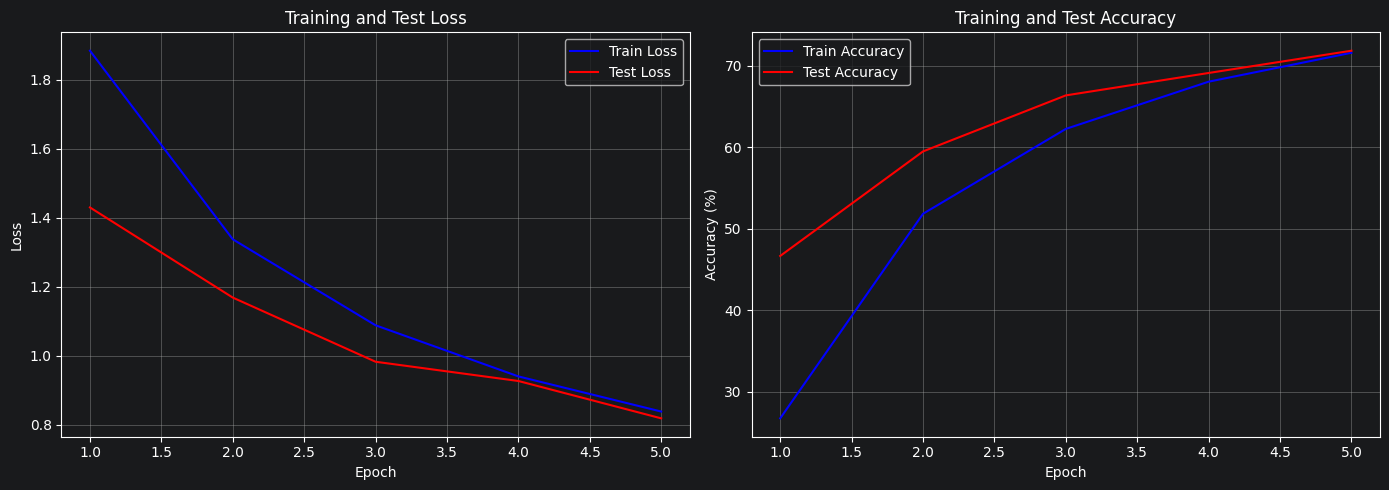

Modèle sauvegardé dans './alexnet_cifar10.pth'


Modèle AlexNet créé et envoyé sur cuda

DÉBUT DE L'ENTRAÎNEMENT

Batch [100/12500], Loss: 2.3002
Batch [200/12500], Loss: 2.3253
Batch [300/12500], Loss: 2.2747
Batch [400/12500], Loss: 2.2904
Batch [500/12500], Loss: 2.3188
Batch [600/12500], Loss: 2.2655
Batch [700/12500], Loss: 2.2852
Batch [800/12500], Loss: 2.3242
Batch [900/12500], Loss: 2.3121
Batch [1000/12500], Loss: 2.2973
Batch [1100/12500], Loss: 2.2970
Batch [1200/12500], Loss: 2.3020
Batch [1300/12500], Loss: 2.3371
Batch [1400/12500], Loss: 2.3212
Batch [1500/12500], Loss: 2.3120
Batch [1600/12500], Loss: 2.2559
Batch [1700/12500], Loss: 2.3200
Batch [1800/12500], Loss: 2.3616
Batch [1900/12500], Loss: 2.4152
Batch [2000/12500], Loss: 2.3998
Batch [2100/12500], Loss: 2.2743
Batch [2200/12500], Loss: 2.2104
Batch [2300/12500], Loss: 2.0310
Batch [2400/12500], Loss: 2.2630
Batch [2500/12500], Loss: 1.9682
Batch [2600/12500], Loss: 2.1317
Batch [2700/12500], Loss: 2.1243
Batch [2800/12500], Loss: 2.1387
Batch [2900/12500], 

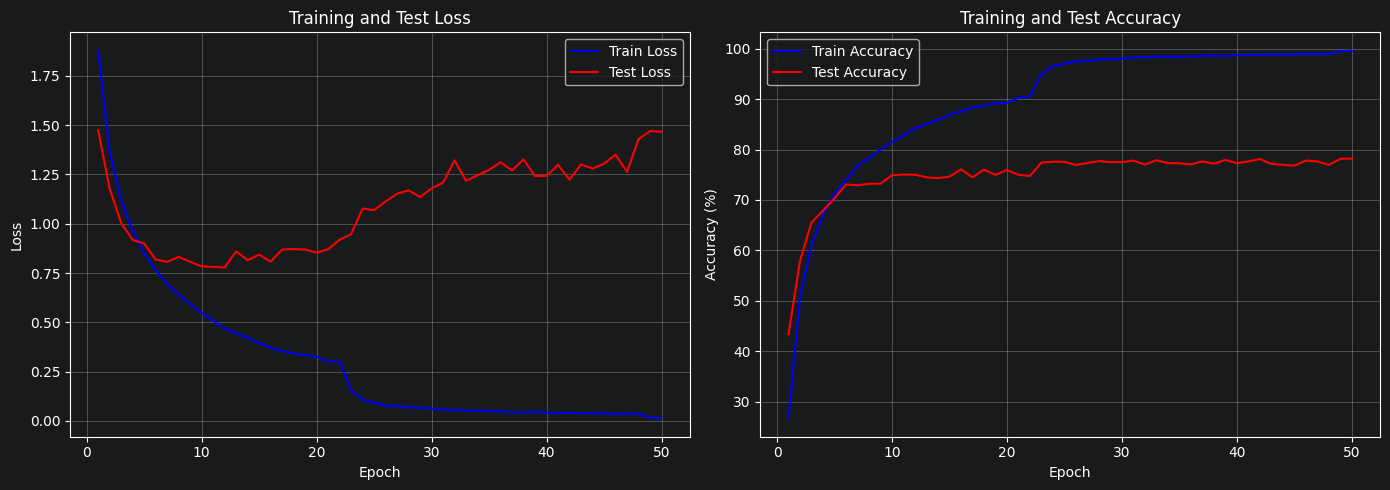

Modèle sauvegardé dans './alexnet_cifar10.pth'


In [23]:
    # ENTRAÎNEMENT COMPLET
if __name__ == "__main__":
    # Hyperparamètres
    NUM_EPOCHS = 50
    BATCH_SIZE = 1000
    LEARNING_RATE = 0.001
    NUM_CLASSES = 10

    # Modèle
    model = AlexNet(num_classes=NUM_CLASSES).to(DEVICE)
    print(f"Modèle AlexNet créé et envoyé sur {DEVICE}")

    # Loss et Optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, factor=0.5, mode='max', patience=5
    )

    # Entraînement
    print("\n" + "=" * 60)
    print("DÉBUT DE L'ENTRAÎNEMENT")
    print("=" * 60 + "\n")

    train_losses, train_accs, test_losses, test_accs = train_model(
        model=model,
        num_epochs=NUM_EPOCHS,
        train_loader=trainloader,
        test_loader=testloader,
        optimizer=optimizer,
        criterion=criterion,
        device=DEVICE,
        scheduler=scheduler
    )

    print("\n" + "=" * 60)
    print("ENTRAÎNEMENT TERMINÉ")
    print("=" * 60)

    # Affichage des courbes
    plot_metrics(train_losses, train_accs, test_losses, test_accs)

    # Sauvegarde du modèle
    torch.save(model.state_dict(), './alexnet_cifar10.pth')
    print("Modèle sauvegardé dans './alexnet_cifar10.pth'")